In [3]:
import os
import sys
import time
import random
import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device configuration (CUDA GPU / Apple Silicon MPS / CPU)
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"Available VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU Model: Tesla T4
Available VRAM: 15.64 GB


In [4]:
# DCGAN Hyperparameters & Configuration
IMAGE_SIZE = 64          # Spatial dimension of images (64x64)
NUM_CHANNELS = 3        # Number of image color channels (RGB = 3)
LATENT_DIM = 100        # Size of the latent z noise vector
FEATURE_MAP_GEN = 64    # Base feature map depth for Generator (ngf)
FEATURE_MAP_DISC = 64   # Base feature map depth for Discriminator (ndf)

BATCH_SIZE = 128        # Batch size during training
NUM_EPOCHS = 25         # Number of training epochs (increase for cloud runs)
LEARNING_RATE = 0.0002  # Learning rate for Adam optimizers
BETA1 = 0.5             # Adam beta1 hyperparameter (crucial for DCGAN stability)
BETA2 = 0.999           # Adam beta2 hyperparameter

# Label smoothing parameters
REAL_LABEL = 0.9        # One-sided label smoothing for real images
FAKE_LABEL = 0.0        # Label for fake images

# Output directories
OUTPUT_DIR = Path("./gan_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLES_DIR = OUTPUT_DIR / "samples"
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration initialized successfully.")

Configuration initialized successfully.


In [5]:
def find_or_download_dataset():
    import kagglehub
    path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
    print(f"Dataset downloaded to: {path}")
    celeba_subpath = os.path.join(path, "img_align_celeba", "img_align_celeba")
    if os.path.exists(celeba_subpath):
        return celeba_subpath
    return path


DATASET_ROOT = find_or_download_dataset()
print(f"Target dataset directory: {DATASET_ROOT}")

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Dataset downloaded to: /kaggle/input/celeba-dataset
Target dataset directory: /kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba


In [ ]:
class FaceDataset(Dataset):
    """
    PyTorch Dataset to load face images from a flat or nested folder.
    Loads and transforms images on the fly with RGB verification.
    """
    def __init__(self, root_dir, transform=None, max_samples=None):
        self.root_dir = root_dir
        self.transform = transform
        
        # Gather all valid image file paths
        valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        self.image_paths = []
        
        for root, _, files in os.walk(root_dir):
            for file in files:
                if Path(file).suffix.lower() in valid_extensions:
                    self.image_paths.append(os.path.join(root, file))
                    
        self.image_paths.sort()
        if max_samples and len(self.image_paths) > max_samples:
            self.image_paths = self.image_paths[:max_samples]
            
        print(f"FaceDataset initialized with {len(self.image_paths)} images from {root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            with Image.open(img_path) as img:
                img = img.convert("RGB")
                if self.transform:
                    img = self.transform(img)
                return img
        except Exception as e:
            # Fallback for corrupted images: pick a random substitute
            rand_idx = random.randint(0, len(self.image_paths) - 1)
            return self.__getitem__(rand_idx)


# Transformations: CenterCrop & Resize to 64x64, then normalize to [-1, 1] range
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Scales [0, 1] to [-1, 1]
])

# Instantiate Dataset & DataLoader
face_dataset = FaceDataset(root_dir=DATASET_ROOT, transform=transform)

# If no images exist (e.g. initial dry run before dataset upload), generate mock samples for verification
if len(face_dataset) == 0:
    print("Creating sample dummy face images for structure verification...")
    dummy_dir = Path("./data/faces/dummy")
    dummy_dir.mkdir(parents=True, exist_ok=True)
    for i in range(256):
        arr = np.random.randint(50, 220, (IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)
        Image.fromarray(arr).save(dummy_dir / f"face_{i:04d}.jpg")
    face_dataset = FaceDataset(root_dir="./data/faces", transform=transform)

dataloader = DataLoader(
    face_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2 if os.name != 'nt' else 0,
    pin_memory=True if torch.cuda.is_available() else False,
    drop_last=True
)

print(f"DataLoader created: {len(dataloader)} batches of size {BATCH_SIZE}.")

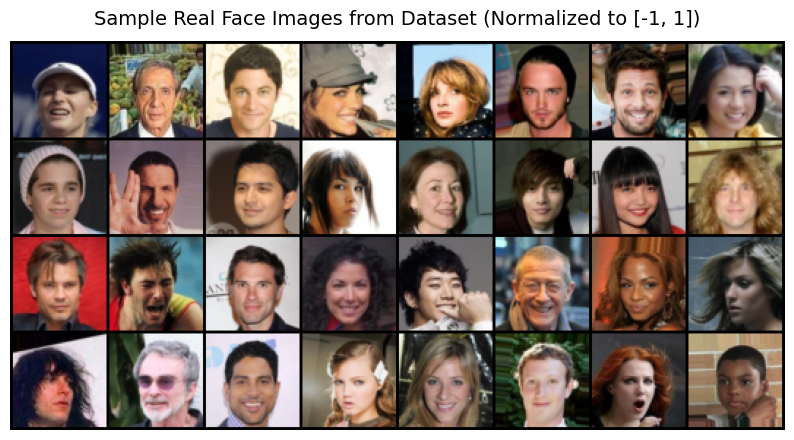

In [6]:
# Visualize a batch of real training faces
real_batch = next(iter(dataloader))

plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Sample Real Face Images from Dataset (Normalized to [-1, 1])", fontsize=14, pad=12)
# Denormalize from [-1, 1] to [0, 1] for visualization: (img * 0.5) + 0.5
grid_img = vutils.make_grid(real_batch[:32], nrow=8, padding=2, normalize=True)
plt.imshow(np.transpose(grid_img.cpu().numpy(), (1, 2, 0)))
plt.show()

In [1]:
def weights_init(m):
    """
    Custom weights initialization called on netG and netD.
    Initializes weights according to DCGAN paper specifications.
    """
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [ ]:
class Generator(nn.Module):
    """
    DCGAN Generator Network:
    Maps latent vector z in R^(LATENT_DIM x 1 x 1) -> RGB Image in R^(3 x 64 x 64).
    """
    def __init__(self, latent_dim=LATENT_DIM, ngf=FEATURE_MAP_GEN, nc=NUM_CHANNELS):
        super(Generator, self).__init__()
        self.latent_dim = latent_dim
        
        self.main = nn.Sequential(
            # Input: Z (latent_dim x 1 x 1) -> Output: (ngf*8) x 4 x 4
            nn.ConvTranspose2d(latent_dim, ngf * 8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            
            # State: (ngf*8) x 4 x 4 -> Output: (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 8, ngf * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            
            # State: (ngf*4) x 8 x 8 -> Output: (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 4, ngf * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            
            # State: (ngf*2) x 16 x 16 -> Output: (ngf) x 32 x 32
            nn.ConvTranspose2d(ngf * 2, ngf, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            
            # State: (ngf) x 32 x 32 -> Output: (nc) x 64 x 64
            nn.ConvTranspose2d(ngf, nc, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()  # Output pixel values in range [-1, 1]
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(-1).unsqueeze(-1)
        return self.main(x)


# Instantiate Generator
netG = Generator().to(device)
netG.apply(weights_init)

# Count and display parameters
num_params_G = sum(p.numel() for p in netG.parameters() if p.requires_grad)
print(f"Generator Initialized. Total Trainable Parameters: {num_params_G:,}")

NameError: name 'nn' is not defined

In [ ]:
class Discriminator(nn.Module):
    """
    DCGAN Discriminator Network:
    Maps RGB Image in R^(3 x 64 x 64) -> Single Scalar Logit (Real/Fake validity score).
    """
    def __init__(self, nc=NUM_CHANNELS, ndf=FEATURE_MAP_DISC):
        super(Discriminator, self).__init__()
        
        self.main = nn.Sequential(
            # Input: (nc) x 64 x 64 -> Output: (ndf) x 32 x 32
            # No BatchNorm on the first layer of the discriminator
            nn.Conv2d(nc, ndf, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: (ndf) x 32 x 32 -> Output: (ndf*2) x 16 x 16
            nn.Conv2d(ndf, ndf * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: (ndf*2) x 16 x 16 -> Output: (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 2, ndf * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: (ndf*4) x 8 x 8 -> Output: (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 4, ndf * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: (ndf*8) x 4 x 4 -> Output: 1 x 1 x 1 (Logit)
            nn.Conv2d(ndf * 8, 1, kernel_size=4, stride=1, padding=0, bias=False)
            # Output is unnormalized logit (used with BCEWithLogitsLoss for numerical stability)
        )

    def forward(self, x):
        out = self.main(x)
        return out.view(-1)  # Flatten to (batch_size,)


# Instantiate Discriminator
netD = Discriminator().to(device)
netD.apply(weights_init)

num_params_D = sum(p.numel() for p in netD.parameters() if p.requires_grad)
print(f"Discriminator Initialized. Total Trainable Parameters: {num_params_D:,}")

Discriminator Initialized. Total Trainable Parameters: 2,765,568
Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bia

In [10]:
# Quick sanity check on forward pass shapes
sample_z = torch.randn(4, LATENT_DIM, 1, 1, device=device)
fake_faces = netG(sample_z)
disc_scores = netD(fake_faces)

print(f"Latent vector shape:       {sample_z.shape}")
print(f"Generated face batch shape: {fake_faces.shape} (Expected: [4, 3, 64, 64])")
print(f"Discriminator logits shape: {disc_scores.shape} (Expected: [4])")
assert fake_faces.shape == (4, 3, 64, 64), "Generator output shape mismatch!"
assert disc_scores.shape == (4,), "Discriminator output shape mismatch!"
print("Forward pass sanity check passed successfully.")

Latent vector shape:       torch.Size([4, 100, 1, 1])
Generated face batch shape: torch.Size([4, 3, 64, 64]) (Expected: [4, 3, 64, 64])
Discriminator logits shape: torch.Size([4]) (Expected: [4])
Forward pass sanity check passed successfully.


## 4. Loss Function & Optimizers

$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log (1 - D(G(z)))]$$

### Numerical Optimization Strategy:

- We use **`nn.BCEWithLogitsLoss()`** which combines a Sigmoid layer and the standard Binary Cross Entropy loss into one single class, avoiding numerical underflow/overflow.
- **One-Sided Label Smoothing**: Real labels are set to $0.9$ instead of $1.0$ to prevent the discriminator from becoming overconfident during early training.
- **Adam Optimizer**: Initialized with $\alpha = 0.0002$ and momentum parameters $\beta_1 = 0.5, \beta_2 = 0.999$.


In [11]:
# Loss criterion (numerically stable BCE with logits)
criterion = nn.BCEWithLogitsLoss()

# Fixed noise vector to visualize consistent face progression throughout training
FIXED_NOISE_SIZE = 64
fixed_noise = torch.randn(FIXED_NOISE_SIZE, LATENT_DIM, 1, 1, device=device)

# Optimizers for Generator and Discriminator
optimizerD = optim.Adam(netD.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
optimizerG = optim.Adam(netG.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))

print("Loss function, fixed noise, and Adam optimizers configured.")

Loss function, fixed noise, and Adam optimizers configured.


In [ ]:
# Tracking training statistics
img_list = []
G_losses = []
D_losses = []
D_x_list = []      # Average D confidence on real images
D_G_z1_list = []   # Average D confidence on fake images before D update
D_G_z2_list = []   # Average D confidence on fake images after G update

print("=" * 70)
print(f"Starting GAN Face Generation Training for {NUM_EPOCHS} Epochs...")
print("=" * 70)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    epoch_d_loss = 0.0
    epoch_g_loss = 0.0
    
    for i, data in enumerate(dataloader):
        # (1) Update Discriminator: maximize log(D(x)) + log(1 - D(G(z)))
        netD.zero_grad()
        
        # Train with all-real batch
        real_images = data.to(device)
        b_size = real_images.size(0)
        
        # Real labels with one-sided label smoothing (0.9)
        labels_real = torch.full((b_size,), REAL_LABEL, dtype=torch.float, device=device)
        
        # Forward pass real batch through D
        output_real = netD(real_images)
        loss_d_real = criterion(output_real, labels_real)
        loss_d_real.backward()
        d_x = torch.sigmoid(output_real).mean().item()
        
        # Train with all-fake batch
        noise = torch.randn(b_size, LATENT_DIM, 1, 1, device=device)
        fake_images = netG(noise)
        labels_fake = torch.full((b_size,), FAKE_LABEL, dtype=torch.float, device=device)
        
        # Forward pass fake batch through D (detach to avoid backprop into G)
        output_fake = netD(fake_images.detach())
        loss_d_fake = criterion(output_fake, labels_fake)
        loss_d_fake.backward()
        d_g_z1 = torch.sigmoid(output_fake).mean().item()
        
        # Total Discriminator loss & optimizer step
        loss_d = loss_d_real + loss_d_fake
        optimizerD.step()
        
        # (2) Update Generator: maximize log(D(G(z)))
        netG.zero_grad()
        
        # Generator wants Discriminator to classify fake images as real (label 1.0)
        labels_gen = torch.full((b_size,), 1.0, dtype=torch.float, device=device)
        
        # Perform forward pass of fake batch through D
        output_g = netD(fake_images)
        loss_g = criterion(output_g, labels_gen)
        loss_g.backward()
        d_g_z2 = torch.sigmoid(output_g).mean().item()
        
        # Generator optimizer step
        optimizerG.step()
        
        # Record batch statistics
        G_losses.append(loss_g.item())
        D_losses.append(loss_d.item())
        D_x_list.append(d_x)
        D_G_z1_list.append(d_g_z1)
        D_G_z2_list.append(d_g_z2)
        
        epoch_d_loss += loss_d.item()
        epoch_g_loss += loss_g.item()
        
        # Print progress every 50 batches or on the last batch
        if (i + 1) % 50 == 0 or (i + 1) == len(dataloader):
            print(f"Epoch [{epoch:02d}/{NUM_EPOCHS:02d}] | Batch [{i+1:04d}/{len(dataloader):04d}] "
                  f"| Loss_D: {loss_d.item():.4f} | Loss_G: {loss_g.item():.4f} "
                  f"| D(x): {d_x:.3f} | D(G(z)): {d_g_z1:.3f} -> {d_g_z2:.3f}")
    
    epoch_duration = time.time() - epoch_start
    avg_d_loss = epoch_d_loss / len(dataloader)
    avg_g_loss = epoch_g_loss / len(dataloader)
    
    print(f"--> Epoch {epoch:02d} Completed in {epoch_duration:.1f}s | Avg Loss_D: {avg_d_loss:.4f} | Avg Loss_G: {avg_g_loss:.4f}")
    
    # Save checkpoint image grid using fixed_noise to track progression
    with torch.no_grad():
        netG.eval()
        fake_samples = netG(fixed_noise).detach().cpu()
        netG.train()
        
        # Make grid and save sample
        sample_grid = vutils.make_grid(fake_samples[:64], nrow=8, padding=2, normalize=True)
        img_list.append(sample_grid)
        
        # Save sample image to disk
        sample_path = SAMPLES_DIR / f"epoch_{epoch:03d}.png"
        vutils.save_image(fake_samples[:64], sample_path, nrow=8, normalize=True)
        
    # Save model weights checkpoint every 5 epochs
    if epoch % 5 == 0 or epoch == NUM_EPOCHS:
        torch.save({
            'epoch': epoch,
            'netG_state_dict': netG.state_dict(),
            'netD_state_dict': netD.state_dict(),
            'optimizerG_state_dict': optimizerG.state_dict(),
            'optimizerD_state_dict': optimizerD.state_dict(),
            'loss_G': avg_g_loss,
            'loss_D': avg_d_loss
        }, CHECKPOINT_DIR / f"dcgan_epoch_{epoch:03d}.pth")
        print(f"Checkpoint saved for epoch {epoch}.")

total_training_time = time.time() - start_time
print(f"Training Completed Successfully in {total_training_time / 60:.2f} minutes.")

Starting GAN Face Generation Training for 25 Epochs...
Epoch [01/25] | Batch [0050/1582] | Loss_D: 0.6430 | Loss_G: 14.3631 | D(x): 0.868 | D(G(z)): 0.000 -> 0.000
Epoch [01/25] | Batch [0100/1582] | Loss_D: 0.5605 | Loss_G: 4.8859 | D(x): 0.843 | D(G(z)): 0.063 -> 0.015
Epoch [01/25] | Batch [0150/1582] | Loss_D: 1.1208 | Loss_G: 2.0998 | D(x): 0.435 | D(G(z)): 0.019 -> 0.162
Epoch [01/25] | Batch [0200/1582] | Loss_D: 0.6866 | Loss_G: 4.3565 | D(x): 0.720 | D(G(z)): 0.113 -> 0.018
Epoch [01/25] | Batch [0250/1582] | Loss_D: 0.9856 | Loss_G: 3.2992 | D(x): 0.530 | D(G(z)): 0.078 -> 0.060
Epoch [01/25] | Batch [0300/1582] | Loss_D: 0.6231 | Loss_G: 3.6729 | D(x): 0.761 | D(G(z)): 0.109 -> 0.037
Epoch [01/25] | Batch [0350/1582] | Loss_D: 1.1366 | Loss_G: 1.4118 | D(x): 0.415 | D(G(z)): 0.053 -> 0.283
Epoch [01/25] | Batch [0400/1582] | Loss_D: 1.1289 | Loss_G: 4.6232 | D(x): 0.849 | D(G(z)): 0.470 -> 0.013


In [ ]:
# 1. Training Loss & Accuracy Dynamics Curves
plt.figure(figsize=(16, 5))

# Plot Generator and Discriminator Losses
plt.subplot(1, 2, 1)
plt.title("Generator and Discriminator Loss During Training", fontsize=13, pad=10)
plt.plot(G_losses, label="Loss_G (Generator)", color="#1f77b4", alpha=0.7)
plt.plot(D_losses, label="Loss_D (Discriminator)", color="#ff7f0e", alpha=0.7)
plt.xlabel("Iterations", fontsize=11)
plt.ylabel("Loss", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=11)

# Plot Discriminator Probabilities D(x) and D(G(z))
plt.subplot(1, 2, 2)
plt.title("Discriminator Confidence Scores D(x) vs D(G(z))", fontsize=13, pad=10)
plt.plot(D_x_list, label="D(x) - Confidence on Real Faces", color="#2ca02c", alpha=0.6)
plt.plot(D_G_z2_list, label="D(G(z)) - Confidence on Fake Faces", color="#d62728", alpha=0.6)
plt.axhline(0.5, color='gray', linestyle=':', label="Ideal Equilibrium (0.5)")
plt.xlabel("Iterations", fontsize=11)
plt.ylabel("Probability", fontsize=11)
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=300)
plt.show()


In [ ]:
# 2. Side-by-Side: Real Training Faces vs Generated Fake Faces
# Get real batch
real_batch = next(iter(dataloader))

# Generate fake faces from the final trained generator
netG.eval()
with torch.no_grad():
    sample_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)
    fake_batch = netG(sample_noise).detach().cpu()

plt.figure(figsize=(16, 8))

# Subplot 1: Real Faces
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Real Face Images (Ground Truth Dataset)", fontsize=14, pad=10)
real_grid = vutils.make_grid(real_batch[:32], nrow=8, padding=2, normalize=True)
plt.imshow(np.transpose(real_grid.cpu().numpy(), (1, 2, 0)))

# Subplot 2: Generated Fake Faces
plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Generated Fake Face Images (DCGAN Synthesis)", fontsize=14, pad=10)
fake_grid = vutils.make_grid(fake_batch[:32], nrow=8, padding=2, normalize=True)
plt.imshow(np.transpose(fake_grid.numpy(), (1, 2, 0)))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "real_vs_fake_comparison.png", dpi=300)
plt.show()

In [ ]:
# 3. High-Quality Gallery of Generated Faces (8x8 Grid = 64 Faces)
with torch.no_grad():
    eval_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)
    generated_faces = netG(eval_noise).detach().cpu()

plt.figure(figsize=(12, 12))
plt.axis("off")
plt.title(f"DCGAN Synthetic Face Generation Gallery ({64} Novel Faces)", fontsize=16, pad=15)
gallery_grid = vutils.make_grid(generated_faces, nrow=8, padding=2, normalize=True)
plt.imshow(np.transpose(gallery_grid.numpy(), (1, 2, 0)))
plt.savefig(OUTPUT_DIR / "generated_face_gallery.png", dpi=300)
plt.show()

In [ ]:
# 4. Latent Space Continuous Interpolation (Face Morphing)
def slerp(val, low, high):
    """Spherical linear interpolation between two latent vectors."""
    low_norm = low / torch.norm(low, dim=1, keepdim=True)
    high_norm = high / torch.norm(high, dim=1, keepdim=True)
    omega = torch.acos(torch.clamp((low_norm * high_norm).sum(dim=1, keepdim=True), -1, 1))
    so = torch.sin(omega)
    if so.item() == 0:
        return (1.0 - val) * low + val * high
    return (torch.sin((1.0 - val) * omega) / so) * low + (torch.sin(val * omega) / so) * high

def interpolate_faces(netG, num_steps=10, num_pairs=4):
    """
    Generates smooth morphing transitions between pairs of random latent points.
    """
    netG.eval()
    fig, axes = plt.subplots(num_pairs, num_steps, figsize=(18, num_pairs * 2.2))
    
    with torch.no_grad():
        for pair_idx in range(num_pairs):
            z1 = torch.randn(1, LATENT_DIM, 1, 1, device=device)
            z2 = torch.randn(1, LATENT_DIM, 1, 1, device=device)
            
            for step_idx, alpha in enumerate(np.linspace(0, 1, num_steps)):
                # Interpolate latent vector
                z_interp = slerp(alpha, z1.view(1, -1), z2.view(1, -1)).view(1, LATENT_DIM, 1, 1)
                img = netG(z_interp).detach().cpu().squeeze(0)
                
                # Denormalize image: (x * 0.5) + 0.5
                img = (img * 0.5 + 0.5).clamp(0, 1)
                img_np = np.transpose(img.numpy(), (1, 2, 0))
                
                ax = axes[pair_idx, step_idx] if num_pairs > 1 else axes[step_idx]
                ax.imshow(img_np)
                ax.axis("off")
                if step_idx == 0:
                    ax.set_title("Source Face", fontsize=9)
                elif step_idx == num_steps - 1:
                    ax.set_title("Target Face", fontsize=9)
                    
    plt.suptitle("Latent Space Continuous Interpolation (Smooth Face Morphing Across Manifold)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "latent_interpolation.png", dpi=300)
    plt.show()

# Run Latent Space Interpolation
interpolate_faces(netG, num_steps=10, num_pairs=4)

In [ ]:
# 5. Individual Generated Face Gallery with Custom Seeds
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

netG.eval()
with torch.no_grad():
    for i in range(10):
        # Generate with distinct random seed
        torch.manual_seed(100 + i)
        z = torch.randn(1, LATENT_DIM, 1, 1, device=device)
        face = netG(z).detach().cpu().squeeze(0)
        face = (face * 0.5 + 0.5).clamp(0, 1)
        face_np = np.transpose(face.numpy(), (1, 2, 0))
        
        axes[i].imshow(face_np)
        axes[i].axis("off")
        axes[i].set_title(f"Synthetic Face #{i+1}", fontsize=11, pad=6)

plt.suptitle("Sample Generated Face Identities (Individual Zoom)", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "individual_faces.png", dpi=300)
plt.show()